# 03 — Connectivity (Course topic L4)

**Semiconductor Supply Chain — Network Analysis**

Which firms hold the network together? We look at **connected components**,
**articulation points** (single firms whose removal disconnects the graph) and
**bridges** (single supply links whose removal does the same) on the directed
`SUPPLIES` projection. This is the structural test of the hypothesis' claim that
a handful of firms are *irreplaceable*.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

ROOT = Path.cwd()
while not (ROOT / 'scripts' / 'analysis.py').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'scripts'))

import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import analysis

D = analysis.company_supply_digraph()
U = D.to_undirected(as_view=False)
print(f'{D.number_of_nodes()} companies, {D.number_of_edges()} SUPPLIES edges')

108 companies, 1256 SUPPLIES edges


## 1. Components

A *weakly* connected component ignores edge direction; a *strongly* connected
one requires a directed path both ways. A supply chain flows upstream→downstream,
so we expect it to be one weak component but almost fully **acyclic**.

In [2]:
print('weakly connected components  :', nx.number_weakly_connected_components(D))
print('strongly connected components:', nx.number_strongly_connected_components(D))
print('undirected — connected?       :', nx.is_connected(U))
print('directed acyclic (DAG)?       :', nx.is_directed_acyclic_graph(D))

gcc = analysis.giant_component(U)
print(f'giant component: {gcc.number_of_nodes()}/{U.number_of_nodes()} nodes '
      f'({gcc.number_of_nodes()/U.number_of_nodes():.0%})')

weakly connected components  : 1
strongly connected components: 108
undirected — connected?       : True
directed acyclic (DAG)?       : True
giant component: 108/108 nodes (100%)


## 2. Articulation points & bridges

An **articulation point** is a node whose removal increases the number of
connected components — a single point of failure for *connectivity*.

In [3]:
ap = sorted(nx.articulation_points(U))
bridges = sorted(nx.bridges(U))
print(f'{len(ap)} articulation point(s): {ap}')
print(f'{len(bridges)} bridge(s): {bridges}')

# global node connectivity = size of the smallest node cut that disconnects U
kappa = nx.node_connectivity(U)
print(f'global node connectivity (kappa) = {kappa}')

1 articulation point(s): ['ASML']
1 bridge(s): [('ASML', 'Carl Zeiss SMT')]
global node connectivity (kappa) = 1


## 3. Why so few? Redundancy vs. pendants

Most tiers have **many** interchangeable suppliers, so removing one rarely
disconnects anyone. The exceptions are **pendant** firms (degree 1) that hang off
a single partner — they are what the articulation point / bridge protects.

In [4]:
pendants = sorted(n for n, d in U.degree() if d == 1)
print(f'{len(pendants)} pendant (degree-1) firms:')
for p in pendants:
    nb_ = next(iter(U.neighbors(p)))
    print(f'  {p:28s} -> only links via {nb_}')

1 pendant (degree-1) firms:
  Carl Zeiss SMT               -> only links via ASML


## 4. Visualise — the single articulation point

Node size ∝ degree, colour = tier, **red ring** = articulation point.

saved

 C:\Users\Max\Desktop\project\reports\figures\03_connectivity.png


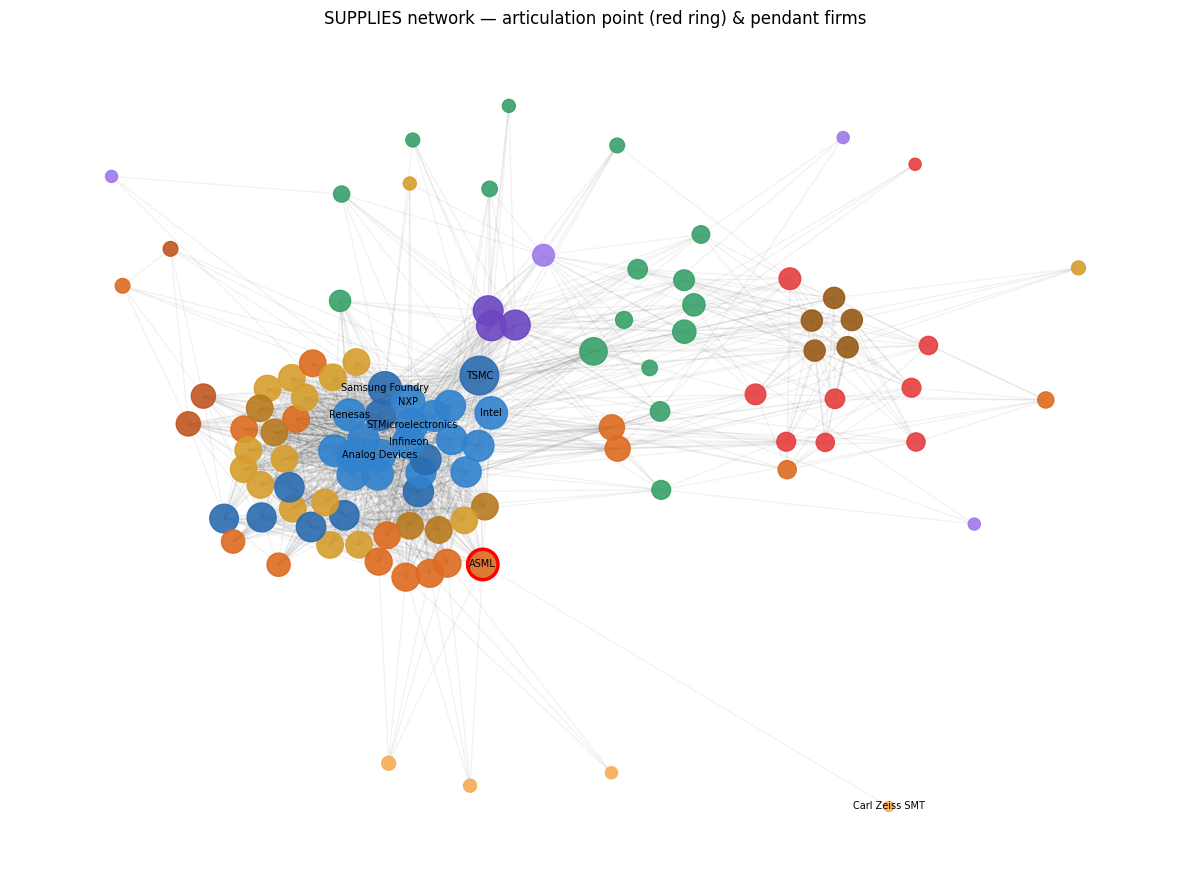

In [5]:
fig, ax = plt.subplots(figsize=(12, 9))
pos = nx.spring_layout(U, seed=42, k=0.30)
colors = [analysis.tier_color(U.nodes[n].get('type')) for n in U.nodes()]
sizes = [40 + 12 * U.degree(n) for n in U.nodes()]
nx.draw_networkx_edges(U, pos, alpha=0.05, ax=ax)
nx.draw_networkx_nodes(U, pos, node_color=colors, node_size=sizes, alpha=0.9, ax=ax)
nx.draw_networkx_nodes(U, pos, nodelist=ap, node_color='none', edgecolors='red',
                       linewidths=2.5, node_size=[120 + 12 * U.degree(n) for n in ap], ax=ax)
top_deg = sorted(U.nodes(), key=lambda n: U.degree(n), reverse=True)[:8]
labels = {n: n for n in set(ap) | set(pendants) | set(top_deg)}
nx.draw_networkx_labels(U, pos, labels=labels, font_size=7, ax=ax)
ax.set_title('SUPPLIES network — articulation point (red ring) & pendant firms')
ax.axis('off')
fig.tight_layout()
out = analysis.FIGURES / '03_connectivity.png'
fig.savefig(out, dpi=130, bbox_inches='tight'); print('saved', out); plt.show()

## 5. Takeaways

- The SUPPLIES projection is **one connected, acyclic (DAG)** flow from upstream
  inputs to downstream integrators — exactly the shape of a supply chain.
- There is **exactly one articulation point — ASML** — joined to the network by a
  single **bridge** (its EUV-optics supplier *Carl Zeiss SMT*, a pendant). Global
  node connectivity is therefore **κ = 1**: one well-chosen removal can split the
  graph.
- Beyond that, the network is **structurally redundant**: every other tier has
  multiple interchangeable suppliers, so single-firm removal does not disconnect
  it. The hypothesis' "irreplaceable firms" claim holds *narrowly* (ASML), not
  broadly — real fragility lives in the **product/material layer** (EUV, ABF
  film), not the aggregate firm graph.

**Next:** `04_communities.ipynb` — Louvain communities and whether the network
clusters by **tier** or by **geography**.